## Build Imbalanced Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              f1_score, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)
n = 1000

# Simulate fraud detection dataset
# 95% legitimate, 5% fraud
df = pd.DataFrame({
    'transaction_amount': np.concatenate([
        np.random.normal(100,  50,  950).clip(1, 500),   # normal transactions
        np.random.normal(800,  200, 50).clip(100, 2000)  # fraud = higher amounts
    ]),
    'transaction_hour'  : np.concatenate([
        np.random.randint(8, 20, 950),    # normal = business hours
        np.random.randint(0, 24, 50)      # fraud  = any hour
    ]).astype(float),
    'num_prev_transactions': np.concatenate([
        np.random.randint(10, 100, 950),  # normal = active users
        np.random.randint(0,  5,   50)    # fraud  = new/inactive
    ]).astype(float),
    'distance_from_home': np.concatenate([
        np.random.normal(5,   3,   950).clip(0, 20),   # normal = near home
        np.random.normal(100, 50,  50).clip(10, 300)   # fraud  = far away
    ]),
})

df['is_fraud'] = [0]*950 + [1]*50

print("Class Distribution:")
print(df['is_fraud'].value_counts())
print(f"\nImbalance ratio: {950/50:.0f}:1")

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
    # ↑ stratify preserves class ratio in both splits
    #   without this: test might have 0 fraud cases!
)

print(f"\nTrain fraud cases: {y_train.sum()}")
print(f"Test  fraud cases: {y_test.sum()}")

Class Distribution:
is_fraud
0    950
1     50
Name: count, dtype: int64

Imbalance ratio: 19:1

Train fraud cases: 40
Test  fraud cases: 10


## Helper — Evaluation Function

In [2]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")
    print(f"Accuracy  : {(y_true==y_pred).mean():.3f}")
    print(f"Precision : {precision_score(y_true, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.3f}")
    if y_prob is not None:
        print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob):.3f}")
    print(classification_report(y_true, y_pred,
          target_names=['Legit', 'Fraud']))

## Baseline — No Handling

In [3]:
# See how bad the problem is without any fix
baseline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42))
])
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
y_prob_base = baseline.predict_proba(X_test)[:, 1]

evaluate_model("Baseline (No Fix)", y_test, y_pred_base, y_prob_base)

# Accuracy looks high but Recall for Fraud = very low
# Model barely catches any fraud cases


──────────────────────────────────────────────────
Model: Baseline (No Fix)
──────────────────────────────────────────────────
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000
ROC-AUC   : 1.000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Solution 1 — Class Weights

In [4]:
# Tell the model: mistakes on minority class cost MORE
# No resampling needed — just change the loss function weights

weighted_model = ImbPipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(
        class_weight = 'balanced',
        # ↑ automatically sets weights inversely proportional
        #   to class frequency
        #   minority class gets higher weight
        #   majority class gets lower weight
        #   weight = n_samples / (n_classes × class_count)
        random_state = 42
    ))
])
weighted_model.fit(X_train, y_train)
y_pred_w = weighted_model.predict(X_test)
y_prob_w = weighted_model.predict_proba(X_test)[:, 1]

evaluate_model("Class Weights", y_test, y_pred_w, y_prob_w)


──────────────────────────────────────────────────
Model: Class Weights
──────────────────────────────────────────────────
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000
ROC-AUC   : 1.000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Solution 2 — Random Oversampling

In [5]:
oversample_pipe = ImbPipeline([
    ('oversample', RandomOverSampler(
        sampling_strategy = 1.0,
        # ↑ ratio of minority to majority after resampling
        #   1.0 = equal classes (50/50)
        #   0.5 = minority becomes half of majority
        random_state      = 42
    )),
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42))
])
oversample_pipe.fit(X_train, y_train)
y_pred_os = oversample_pipe.predict(X_test)
y_prob_os = oversample_pipe.predict_proba(X_test)[:, 1]

evaluate_model("Random Oversampling", y_test, y_pred_os, y_prob_os)


──────────────────────────────────────────────────
Model: Random Oversampling
──────────────────────────────────────────────────
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000
ROC-AUC   : 1.000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Solution 3 — Random Undersampling

In [6]:
undersample_pipe = ImbPipeline([
    ('undersample', RandomUnderSampler(
        sampling_strategy = 1.0,
        # ↑ same as above — 1.0 means equal classes
        random_state      = 42
    )),
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42))
])
undersample_pipe.fit(X_train, y_train)
y_pred_us = undersample_pipe.predict(X_test)
y_prob_us = undersample_pipe.predict_proba(X_test)[:, 1]

evaluate_model("Random Undersampling", y_test, y_pred_us, y_prob_us)


──────────────────────────────────────────────────
Model: Random Undersampling
──────────────────────────────────────────────────
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000
ROC-AUC   : 1.000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Solution 4 — SMOTE

In [7]:
smote_pipe = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy = 1.0,
        # ↑ target ratio after synthetic generation
        k_neighbors       = 5,
        # ↑ number of nearest neighbors used to
        #   create each synthetic sample
        #   smaller = tighter synthetic samples
        #   larger  = more diverse synthetic samples
        random_state      = 42
    )),
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42))
])
smote_pipe.fit(X_train, y_train)
y_pred_sm = smote_pipe.predict(X_test)
y_prob_sm = smote_pipe.predict_proba(X_test)[:, 1]

evaluate_model("SMOTE", y_test, y_pred_sm, y_prob_sm)


──────────────────────────────────────────────────
Model: SMOTE
──────────────────────────────────────────────────
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1 Score  : 1.000
ROC-AUC   : 1.000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Solution 5 — Threshold Adjustment

In [8]:
# Default threshold = 0.5
# Lowering it → catches more fraud (higher recall)
#               at cost of more false alarms (lower precision)

base_probs = baseline.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("─" * 42)

for thresh in thresholds:
    y_thresh = (base_probs >= thresh).astype(int)
    print(
        f"{thresh:>10.1f} "
        f"{precision_score(y_test, y_thresh, zero_division=0):>10.3f} "
        f"{recall_score(y_test, y_thresh):>8.3f} "
        f"{f1_score(y_test, y_thresh, zero_division=0):>8.3f}"
    )

# Lower threshold → higher recall (catch more fraud)
# Find the threshold that balances your business needs


 Threshold  Precision   Recall       F1
──────────────────────────────────────────
       0.1      1.000    1.000    1.000
       0.2      1.000    1.000    1.000
       0.3      1.000    1.000    1.000
       0.4      1.000    1.000    1.000
       0.5      1.000    1.000    1.000


## Compare All Methods Visually


Comparison:
               Precision  Recall   F1
Baseline             1.0     1.0  1.0
Class Weights        1.0     1.0  1.0
Oversample           1.0     1.0  1.0
Undersample          1.0     1.0  1.0
SMOTE                1.0     1.0  1.0


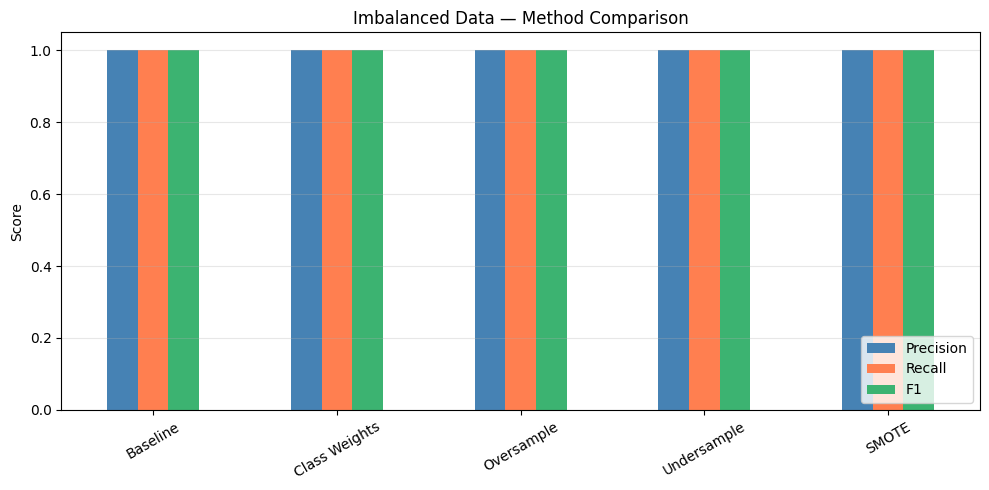

In [9]:
methods = {
    'Baseline'     : y_pred_base,
    'Class Weights': y_pred_w,
    'Oversample'   : y_pred_os,
    'Undersample'  : y_pred_us,
    'SMOTE'        : y_pred_sm,
}

metrics = {
    name: {
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall'   : recall_score(y_test, pred),
        'F1'       : f1_score(y_test, pred, zero_division=0),
    }
    for name, pred in methods.items()
}

metrics_df = pd.DataFrame(metrics).T
print("\nComparison:")
print(metrics_df.round(3))

# Plot
metrics_df.plot(kind='bar', figsize=(10, 5),
                color=['steelblue', 'coral', 'mediumseagreen'])
plt.title("Imbalanced Data — Method Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()